In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

INPUT = Path("/kaggle/input")
print("Attached datasets:", [d.name for d in sorted(INPUT.iterdir())])

# Two tensor stores are attached. The merged one (one row per mammogram, all
# lesions in one mask) trains and monitors; the per-lesion one scores cell 5 so
# the gate figure is on the same rows as run 1. Tell them apart by the meta
# schema rather than the dataset name, which is free text.
def _is_merged(meta_csv: Path) -> bool:
    return "n_lesions" in pd.read_csv(meta_csv, nrows=1).columns

stores = {hit.parent: _is_merged(hit.parent / "train_meta.csv")
          for hit in INPUT.glob("**/train_images.npy")}
assert stores, "train_images.npy not found - are the tensor datasets attached?"
merged = [p for p, m in stores.items() if m]
lesion = [p for p, m in stores.items() if not m]
assert len(merged) == 1, f"expected exactly one MERGED store, found {merged}"
assert len(lesion) == 1, f"expected exactly one PER-LESION store, found {lesion}"
TENSORS, TENSORS_LESION = merged[0], lesion[0]

src_hits = list(INPUT.glob("**/src/localise.py"))
assert src_hits, ("src/localise.py not found - attach the src dataset. The "
                  "folder must be named 'src' for the relative imports to work.")
SRC_PARENT = src_hits[0].parent.parent
sys.path.insert(0, str(SRC_PARENT))

from src import config
from src.localise import (build_unet, bce_dice_loss, dice_coefficient,
                          hard_iou, _augment_pair, mask_to_box, box_iou)

# Run-3 guard. Kaggle pins a dataset VERSION, so a Save & Run All against the
# previous ddsm-src looks entirely normal until you read the manifest four
# hours later. Must come AFTER the import: config does not exist before it.
assert config.LOC_BASE_FILTERS == 32, f"stale src: filters={config.LOC_BASE_FILTERS}"
assert config.LOC_BATCH_SIZE == 4, f"stale src: batch={config.LOC_BATCH_SIZE}"
assert config.LOC_RLROP_PATIENCE == 8, f"stale src: rlrop={config.LOC_RLROP_PATIENCE}"
assert hasattr(config, "LOC_TENSORS_MERGED_DIR"), "stale src: pre-run-3 config"
print(f"[run3] filters={config.LOC_BASE_FILTERS} depth={config.LOC_DEPTH} "
      f"batch={config.LOC_BATCH_SIZE} lr={config.LOC_LR} "
      f"epochs={config.LOC_EPOCHS} rlrop={config.LOC_RLROP_PATIENCE} "
      f"es_patience={config.LOC_PATIENCE} mask_thr={config.LOC_MASK_THRESHOLD}")

RUN = "run3_base32_merged"
OUT = Path("/kaggle/working") / RUN
OUT.mkdir(parents=True, exist_ok=True)
config.set_seeds(config.SEED)

gpu = tf.config.list_physical_devices("GPU")
assert gpu, "No GPU - set Accelerator to GPU T4 in Session options"

print(f"TENSORS (merged, training)   = {TENSORS}")
print(f"TENSORS_LESION (cell 5 gate) = {TENSORS_LESION}")
print(f"SRC path = {SRC_PARENT}")
print(f"GPU      = {gpu}")
print(f"canvas {config.LOC_INPUT_H}x{config.LOC_INPUT_W} | seed {config.SEED}")
print(f"OUT      = {OUT}")

Attached datasets: ['datasets']
[run3] filters=32 depth=4 batch=4 lr=0.001 epochs=120 rlrop=8 es_patience=20 mask_thr=0.1
TENSORS (merged, training)   = /kaggle/input/datasets/tataruteodor/ddsm-localiser-tensors-merged
TENSORS_LESION (cell 5 gate) = /kaggle/input/datasets/tataruteodor/localiser-tensors
SRC path = /kaggle/input/datasets/tataruteodor/ddsm-src
GPU      = [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
canvas 1024x576 | seed 28
OUT      = /kaggle/working/run3_base32_merged


I0000 00:00:1788788436.266846      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788788436.269648      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [2]:
BATCH = config.LOC_BATCH_SIZE

def make_ds(root, split, batch=BATCH, shuffle=False, augment=False):
    """Datasets straight from precomputed letterboxed tensors (no decode, no cache)."""
    imgs = np.load(root / f"{split}_images.npy")
    msks = np.load(root / f"{split}_masks.npy")
    scale = 255.0 if imgs.dtype == np.uint8 else 1.0
    print(f"{root.name}/{split}: {len(imgs)} pairs | {imgs.dtype} | "
          f"{imgs.nbytes/1e6:.0f} MB | mean fg {msks.mean():.5f}")
    ds = tf.data.Dataset.from_tensor_slices((imgs, msks)).map(
        lambda i, m: (tf.cast(i, tf.float32)[..., None] / scale,
                      tf.cast(m, tf.float32)[..., None]),
        num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(len(imgs), seed=config.SEED, reshuffle_each_iteration=True)
    ds = ds.batch(batch)
    if augment:
        ds = ds.map(_augment_pair, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE), float(msks.mean()), len(imgs)

# Merged store: one row per mammogram. Train 1146 images (1210 lesions),
# val 225 (243). No test_ds: the localiser never trains or monitors on test.
train_ds, FG_PRIOR, N_TRAIN = make_ds(TENSORS, "train", shuffle=True, augment=True)
val_ds, _, N_VAL = make_ds(TENSORS, "val")
assert N_TRAIN == 1146 and N_VAL == 225, f"unexpected merged sizes {N_TRAIN}/{N_VAL}"

i0, m0 = next(iter(train_ds))
print(f"\nbatch {i0.shape} range [{tf.reduce_min(i0):.3f}, {tf.reduce_max(i0):.3f}]"
      f" | fg {m0.numpy().mean():.5f} | train fg prior {FG_PRIOR:.5f}")
assert tf.reduce_max(i0) > 0.5, "images look wrong - check the dtype/scale"
assert 0.0001 < m0.numpy().mean() < 0.2, "masks look wrong - check the upload"

ddsm-localiser-tensors-merged/train: 1146 pairs | float16 | 1352 MB | mean fg 0.00497
ddsm-localiser-tensors-merged/val: 225 pairs | float16 | 265 MB | mean fg 0.00445

batch (4, 1024, 576, 1) range [0.000, 1.000] | fg 0.00571 | train fg prior 0.00497


In [3]:
# float32 throughout. Run 2 (mixed_float16, base 48) went NaN at epoch 29 with
# the signature of an fp16 overflow reaching BatchNorm's moving statistics,
# which loss scaling does not protect. Base 32 at batch 4 fits a T4 in float32
# (batch 8 does not); expect roughly 2x run 1's epoch time.
tf.keras.mixed_precision.set_global_policy("float32")
print("policy:", tf.keras.mixed_precision.global_policy().name)

# Output bias initialised to the MERGED store's foreground rate, not the
# per-lesion 0.0034: the prior is a property of the training targets.
model = build_unet(output_prior=FG_PRIOR)
model.compile(optimizer=tf.keras.optimizers.Adam(config.LOC_LR),
              loss=bce_dice_loss, metrics=[dice_coefficient, hard_iou])

bias = float(model.get_layer("lesion_prob").get_weights()[1][0])
expected_bias = float(np.log(FG_PRIOR / (1.0 - FG_PRIOR)))
print(f"{model.count_params():,} params   (run 1 = 7,768,353)")
print(f"output bias  = {bias:.3f}   (expected {expected_bias:.3f})")
assert abs(bias - expected_bias) < 1e-3, "output bias not prior-initialised"
assert model.count_params() == 7_768_353, "not the run-1 architecture"

policy: float32
7,768,353 params   (run 1 = 7,768,353)
output bias  = -5.300   (expected -5.300)


In [4]:
EPOCHS = config.LOC_EPOCHS

cbs = [
    # Selection on val_loss for all three callbacks (see run 2's rationale):
    # val_hard_iou is a noisy snapshot, val_loss is smooth and is what the model
    # optimises, and this way the restored model and the file on disk are the
    # same model by construction.
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", mode="min",
        patience=config.LOC_PATIENCE,
        start_from_epoch=config.LOC_START_FROM_EPOCH,
        restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", mode="min", factor=0.5,
        patience=config.LOC_RLROP_PATIENCE, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint(
        str(OUT / "best.weights.h5"), monitor="val_loss", mode="min",
        save_best_only=True, save_weights_only=True, verbose=1),
    # Run 2 burned 19 epochs after it had diverged. Stop at the first NaN; the
    # weights-only checkpoint above already holds the last good epoch.
    tf.keras.callbacks.TerminateOnNaN(),
    tf.keras.callbacks.CSVLogger(str(OUT / "history.csv")),
]

history = model.fit(train_ds, validation_data=val_ds,
                    epochs=EPOCHS, callbacks=cbs, verbose=1)

Epoch 1/120


2026-09-07 13:41:21.762809: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:41:21.925861: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:41:22.090017: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:41:36.961513: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:41:37.155721: E external/local_xla/xla/stream_

286/287 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - dice_coefficient: 0.0810 - hard_iou: 0.0646 - loss: 0.4804

2026-09-07 13:45:43.055479: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:45:43.221967: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:45:53.189598: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:45:53.388597: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:45:54.482864: E external/local_xla/xla/stream_

287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 853ms/step - dice_coefficient: 0.0810 - hard_iou: 0.0646 - loss: 0.4804

2026-09-07 13:46:36.295853: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:46:36.443224: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:46:42.223919: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 13:46:42.392375: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.



Epoch 1: val_loss improved from None to 0.56749, saving model to /kaggle/working/run3_base32_merged/best.weights.h5

Epoch 1: finished saving model to /kaggle/working/run3_base32_merged/best.weights.h5
287/287 ━━━━━━━━━━━━━━━━━━━━ 339s 933ms/step - dice_coefficient: 0.0843 - hard_iou: 0.0648 - loss: 0.4769 - val_dice_coefficient: 0.0010 - val_hard_iou: 0.0000e+00 - val_loss: 0.5675 - learning_rate: 0.0010
Epoch 2/120
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 720ms/step - dice_coefficient: 0.0955 - hard_iou: 0.0701 - loss: 0.4705
Epoch 2: val_loss improved from 0.56749 to 0.51578, saving model to /kaggle/working/run3_base32_merged/best.weights.h5

Epoch 2: finished saving model to /kaggle/working/run3_base32_merged/best.weights.h5
287/287 ━━━━━━━━━━━━━━━━━━━━ 221s 763ms/step - dice_coefficient: 0.0919 - hard_iou: 0.0667 - loss: 0.4722 - val_dice_coefficient: 0.0020 - val_hard_iou: 1.0098e-04 - val_loss: 0.5158 - learning_rate: 0.0010
Epoch 3/120
287/287 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - dice_

{
  "run": "run3_base32_merged",
  "device": "{'compute_capability': (7, 5), 'device_name': 'Tesla T4'}",
  "train_store": "merged (one row per mammogram, union of lesion masks)",
  "n_train_images": 1146,
  "n_val_images": 225,
  "n_train_lesions": 1210,
  "n_val_lesions": 243,
  "lr": 0.001,
  "batch_size": 4,
  "epochs_requested": 120,
  "epochs_run": 80,
  "first_nan_epoch": null,
  "seed": 28,
  "input": [
    1024,
    576
  ],
  "depth": 4,
  "base_filters": 32,
  "params": 7768353,
  "dice_bce_weights": [
    0.5,
    0.5
  ],
  "output_prior": 0.0049667180867442005,
  "output_prior_bias": -5.3000168800354,
  "input_dtype": "float16",
  "precision": "float32",
  "steps_per_epoch": 287,
  "selection_metric": "val_loss",
  "early_stopping_patience": 20,
  "start_from_epoch": 20,
  "rlrop_patience": 8,
  "hard_iou_threshold": 0.1,
  "best_epoch": 60,
  "val_loss_at_best_epoch": 0.2712482810020447,
  "val_hard_iou_at_best_epoch": 0.38361385464668274,
  "val_dice_at_best_epoch": 0.4

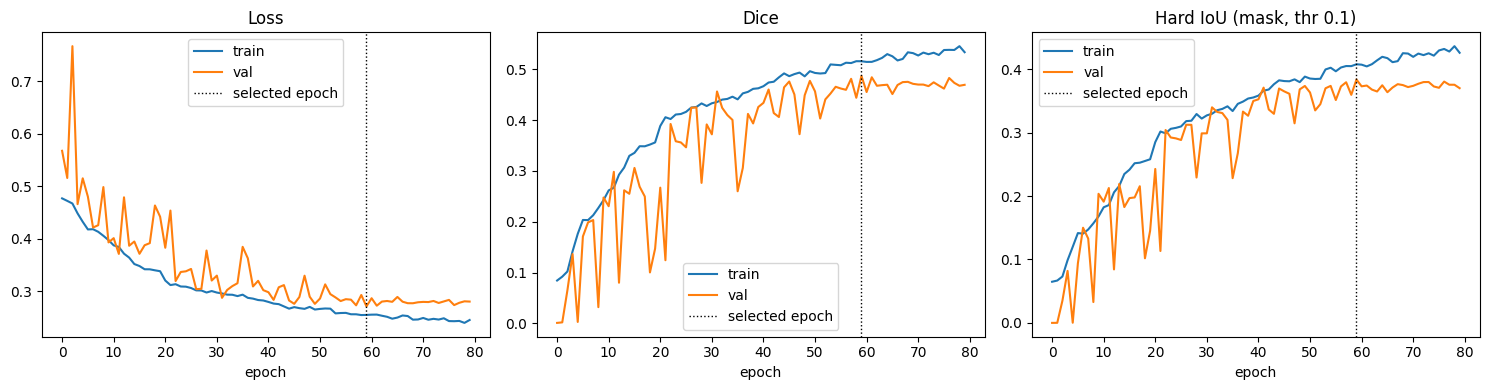

In [5]:
h = history.history
vl = np.asarray(h["val_loss"], dtype=float)
finite = np.isfinite(vl)
assert finite.any(), "every epoch's val_loss is NaN - nothing to select"
best_i = int(np.nanargmin(vl))                     # NaN-safe: run 2's manifest was not
first_nan = int(np.argmax(~finite)) if (~finite).any() else None

manifest = {
    "run": RUN,
    "device": str(tf.config.experimental.get_device_details(gpu[0])),
    "train_store": "merged (one row per mammogram, union of lesion masks)",
    "n_train_images": N_TRAIN, "n_val_images": N_VAL,
    "n_train_lesions": 1210, "n_val_lesions": 243,
    "lr": config.LOC_LR,
    "batch_size": BATCH,
    "epochs_requested": EPOCHS,
    "epochs_run": len(h["loss"]),
    "first_nan_epoch": None if first_nan is None else first_nan + 1,
    "seed": config.SEED,
    "input": [config.LOC_INPUT_H, config.LOC_INPUT_W],
    "depth": config.LOC_DEPTH,
    "base_filters": config.LOC_BASE_FILTERS,
    "params": int(model.count_params()),
    "dice_bce_weights": list(config.LOC_DICE_BCE_WEIGHTS),
    "output_prior": FG_PRIOR,
    "output_prior_bias": bias,
    "input_dtype": str(np.load(TENSORS / "train_images.npy", mmap_mode="r").dtype),
    "precision": tf.keras.mixed_precision.global_policy().name,
    "steps_per_epoch": int(np.ceil(N_TRAIN / BATCH)),
    "selection_metric": "val_loss",
    "early_stopping_patience": config.LOC_PATIENCE,
    "start_from_epoch": config.LOC_START_FROM_EPOCH,
    "rlrop_patience": config.LOC_RLROP_PATIENCE,
    # hard_iou here is at config.LOC_MASK_THRESHOLD (0.10), not run 1/2's 0.5,
    # and on MERGED val rows. Monitoring only; the comparable numbers come from
    # local localise_eval on the per-lesion store.
    "hard_iou_threshold": config.LOC_MASK_THRESHOLD,
    "best_epoch": best_i + 1,
    "val_loss_at_best_epoch": float(vl[best_i]),
    "val_hard_iou_at_best_epoch": float(h["val_hard_iou"][best_i]),
    "val_dice_at_best_epoch": float(h["val_dice_coefficient"][best_i]),
    "train_hard_iou_at_best_epoch": float(h["hard_iou"][best_i]),
    "max_val_hard_iou_any_epoch": float(np.nanmax(h["val_hard_iou"])),
    "max_val_dice_any_epoch": float(np.nanmax(h["val_dice_coefficient"])),
    "final_train_loss": float(h["loss"][-1]),
    "all_background_loss_per_lesion_store": 0.534,
}
(OUT / "manifest.json").write_text(json.dumps(manifest, indent=2))
print(json.dumps(manifest, indent=2))

gap = (manifest["train_hard_iou_at_best_epoch"]
       - manifest["val_hard_iou_at_best_epoch"])
print(f"\ntrain - val hard_iou at the selected epoch: {gap:+.4f}")
print("run 1 pace on val_loss: 0.365 @12, 0.351 @20, 0.311 @26, 0.288 @38, 0.280 @49")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(axes, ["loss", "dice_coefficient", "hard_iou"],
                          ["Loss", "Dice", f"Hard IoU (mask, thr {config.LOC_MASK_THRESHOLD})"]):
    ax.plot(h[key], label="train")
    ax.plot(h[f"val_{key}"], label="val")
    ax.axvline(best_i, ls=":", c="k", lw=1, label="selected epoch")
    ax.set_title(title); ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout()
fig.savefig(OUT / "training_curves.png", dpi=150)
plt.show()

60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step

2026-09-07 18:37:01.301535: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 18:37:01.472547: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 18:37:15.209523: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-07 18:37:15.416587: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


61/61 ━━━━━━━━━━━━━━━━━━━━ 32s 514ms/step

val lesions 243 | with GT box 243 | no GT 0
threshold 0.1 | min_px 64
Detection rate (a box was produced): 89.7%
Box IoU, miss-inclusive   mean 0.387 | median 0.498   <-- GATE METRIC
Box IoU, given detection  mean 0.432 | median 0.580
IoU >= 0.50: 49.8%   IoU >= 0.30: 55.1%
Run 1 at the same threshold (local localise_eval): 0.385 | 90.1% | 50.2%

W20 GATE: PASS - keep the supervised localiser


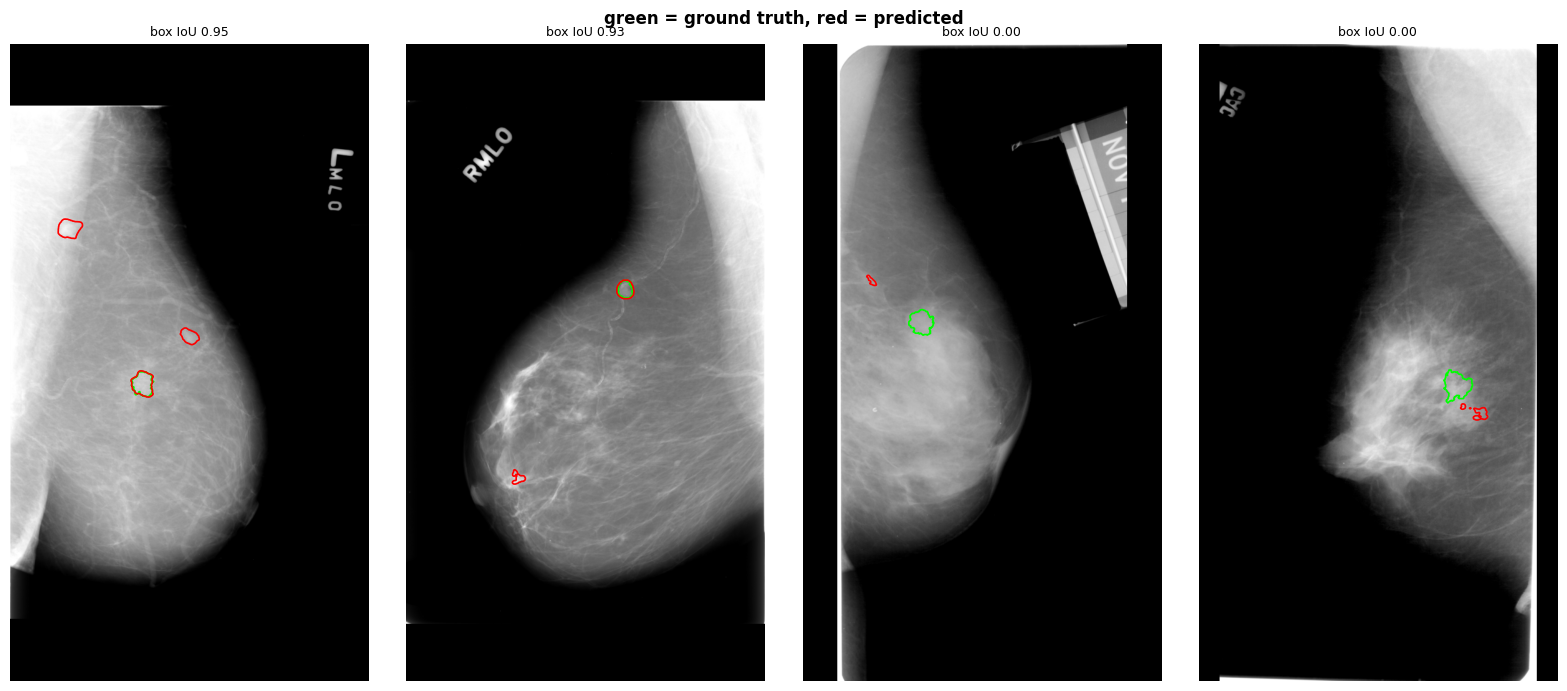

In [6]:
# Gate figure on the PER-LESION validation store (243 rows), so it is on the
# same rows as run 1. mask_to_box uses config thresholds (0.10, min_px 64,
# largest component) - the same as local localise_eval - so the reference is
# run 1's validation miss-inclusive box IoU 0.3853 / detection 0.9012 /
# IoU>=0.5 0.5021 (mammogram-space; canvas-space is within 0.003 of it).
imgs = np.load(TENSORS_LESION / "val_images.npy")
msks = np.load(TENSORS_LESION / "val_masks.npy")
scale = 255.0 if imgs.dtype == np.uint8 else 1.0

probs = model.predict(imgs.astype(np.float32)[..., None] / scale,
                      batch_size=BATCH, verbose=1)[..., 0]

rows = []
for i in range(len(imgs)):
    gt = mask_to_box(msks[i].astype(np.float32), threshold=0.5,
                     min_px=1, keep_largest=False)
    pr = mask_to_box(probs[i])
    if gt is None:
        iou = np.nan
    elif pr is None:
        iou = 0.0
    else:
        iou = box_iou(gt, pr)
    rows.append({"i": i, "has_gt": gt is not None,
                 "detected": pr is not None, "box_iou": iou})

r = pd.DataFrame(rows)
scored = r[r["has_gt"]]
det = scored[scored["detected"]]

print(f"\nval lesions {len(r)} | with GT box {len(scored)} | no GT {int((~r['has_gt']).sum())}")
print(f"threshold {config.LOC_MASK_THRESHOLD} | min_px {config.LOC_MIN_COMPONENT_PX}")
print(f"Detection rate (a box was produced): {scored['detected'].mean():.1%}")
print(f"Box IoU, miss-inclusive   mean {scored['box_iou'].mean():.3f} "
      f"| median {scored['box_iou'].median():.3f}   <-- GATE METRIC")
print(f"Box IoU, given detection  mean {det['box_iou'].mean():.3f} "
      f"| median {det['box_iou'].median():.3f}")
print(f"IoU >= 0.50: {(scored['box_iou'] >= 0.5).mean():.1%}   "
      f"IoU >= 0.30: {(scored['box_iou'] >= 0.3).mean():.1%}")
print("Run 1 at the same threshold (local localise_eval): 0.385 | 90.1% | 50.2%")

gate = scored["box_iou"].mean() >= 0.30
print(f"\nW20 GATE: "
      f"{'PASS - keep the supervised localiser' if gate else 'FAIL - fall back to CAM-only'}")

best = scored.sort_values("box_iou", ascending=False)
show = list(best["i"][:2]) + list(best["i"][-2:])
fig, axes = plt.subplots(1, 4, figsize=(16, 7))
for ax, i in zip(axes, show):
    ax.imshow(imgs[i].astype(np.float32) / scale, cmap="gray")
    ax.contour(msks[i], levels=[0.5], colors="lime", linewidths=1.2)
    ax.contour(probs[i], levels=[config.LOC_MASK_THRESHOLD], colors="red", linewidths=1.2)
    ax.set_title(f"box IoU {r.loc[i, 'box_iou']:.2f}", fontsize=9)
    ax.axis("off")
plt.suptitle("green = ground truth, red = predicted", fontweight="bold")
plt.tight_layout()
fig.savefig(OUT / "prediction_examples.png", dpi=150)
plt.show()